<a href="https://colab.research.google.com/github/kowsik005/ml_supervised_project/blob/main/Untitled1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Optimal Penalty (Alpha): 0.1064
Mean Squared Error (MSE): 5.04
R² Score: 0.9834

--- Lasso Learned Coefficients ---
         Feature  Lasso_Coefficient
Random_Feature_0          12.744809
Random_Feature_1          -9.893825
Random_Feature_2           0.000000
Random_Feature_3           0.070220
Random_Feature_4          -0.142990
Random_Feature_5          -0.094125
Random_Feature_6           0.000000
Random_Feature_7           0.000000


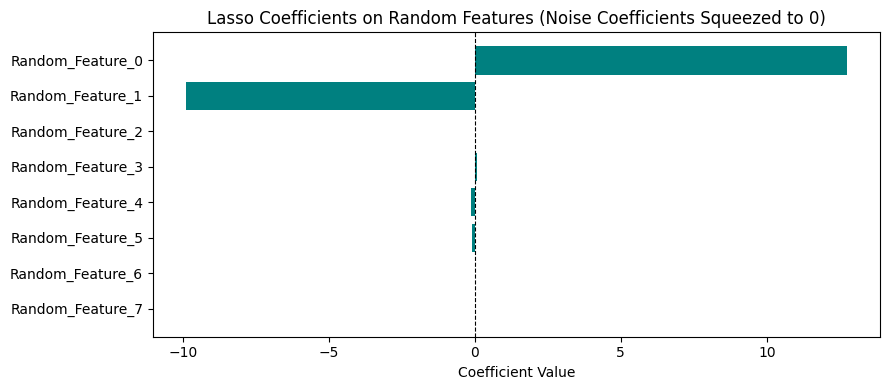

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, r2_score

# 1. Generate purely random numbers in memory
np.random.seed(42)
n_samples = 200
n_features = 8

# Generate random feature matrix X
X_raw = np.random.randn(n_samples, n_features)

# Define target y with only Feature_0 and Feature_1 contributing true signal
# Features 2 through 7 are pure random noise
y_raw = (15 * X_raw[:, 0]) - (10 * X_raw[:, 1]) + np.random.randn(n_samples) * 2

feature_names = [f'Random_Feature_{i}' for i in range(n_features)]
X = pd.DataFrame(X_raw, columns=feature_names)
y = pd.Series(y_raw, name='Target')

# 2. Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale Features (Essential for Regularization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Lasso with Cross-Validation to auto-tune Alpha
lasso_cv = LassoCV(cv=5, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

# 5. Evaluate Model Performance
y_pred = lasso_cv.predict(X_test_scaled)

print(f"Optimal Penalty (Alpha): {lasso_cv.alpha_:.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.2f}")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}\n")

# 6. Show Feature Selection (Zeroed-out noise features)
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Lasso_Coefficient': lasso_cv.coef_
})

print("--- Lasso Learned Coefficients ---")
print(coef_df.to_string(index=False))

# 7. Plot Coefficients
plt.figure(figsize=(9, 4))
plt.barh(coef_df['Feature'], coef_df['Lasso_Coefficient'], color='teal')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title("Lasso Coefficients on Random Features (Noise Coefficients Squeezed to 0)")
plt.xlabel("Coefficient Value")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()